**Ch121a | Module 3: Periodic DFT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module3_Periodic-DFT/notebooks/01_finite_to_periodic_dft.ipynb)

# Notebook 1: From Finite to Periodic DFT

---

## Learning Objectives

- From molecular to periodic DFT
- **Supercell** and periodic boundary conditions (PBC)
- Bloch's theorem and crystal momentum **k**
- Brillouin zone (BZ), reciprocal lattice, and high-symmetry points
- Band structure diagrams to molecular orbital (MO) diagrams
- Main application domains of periodic DFT

## 1. From Molecules to Crystals: What Changes?

In **molecular (finite) DFT** (Module 1), the system is isolated: atoms sit in a vacuum box, and the wavefunction decays to zero at the boundaries. In **periodic DFT**, the system repeats infinitely in one or more directions via **periodic boundary conditions (PBC)**, that we already understood in the context of classical MD simulations (Module 2).

### Supercell

The fundamental unit of a periodic calculation is the **supercell** — a parallelepiped defined by three lattice vectors **a₁**, **a₂**, **a₃**. The infinite crystal is obtained by repeating this cell in all directions:

$$\mathbf{R} = n_1 \mathbf{a}_1 + n_2 \mathbf{a}_2 + n_3 \mathbf{a}_3 \quad (n_1, n_2, n_3 \in \mathbb{Z})$$

Implications:
- **No molecular edges** — atoms near the cell boundary interact with images on the opposite side
- **Basis set changes** — plane-waves (periodic) replace Gaussian orbitals (localized)
- **k-point sampling** — replaces the single-point evaluation of a molecule

### POSCAR Example: Si Conventional Cell

```
Si
1.0
  5.4310  0.0000  0.0000
  0.0000  5.4310  0.0000
  0.0000  0.0000  5.4310
Si
8
Direct
  0.000  0.000  0.000
  0.250  0.250  0.250
  0.500  0.500  0.000
  0.750  0.750  0.250
  0.500  0.000  0.500
  0.750  0.250  0.750
  0.000  0.500  0.500
  0.250  0.750  0.750
```

In [15]:
from ase.io import read
import py3Dmol
import numpy as np

atoms = read("../tmp/POSCAR_sample")

symbols = atoms.get_chemical_symbols()
positions = atoms.get_positions()

xyz_str = f"{len(symbols)}\nPOSCAR\n"
for s, (x, y, z) in zip(symbols, positions):
    xyz_str += f"{s} {x:.6f} {y:.6f} {z:.6f}\n"

cell = atoms.get_cell()      # 3x3 lattice vectors
a, b, c = cell[0], cell[1], cell[2]

origin = np.zeros(3)

corners = [
    origin,
    a,
    b,
    c,
    a + b,
    a + c,
    b + c,
    a + b + c
]

edges = [
    (0,1), (0,2), (0,3),
    (1,4), (1,5),
    (2,4), (2,6),
    (3,5), (3,6),
    (4,7), (5,7), (6,7)
]
view = py3Dmol.view(width=800, height=500)

# Add atomic structure
view.addModel(xyz_str, "xyz")
view.setStyle({
    'sphere': {'scale': 0.5,
        'shininess': 80,
        'specular': 'white'
},
    'stick': {'radius': 0.15}
})
for i, j in edges:
    p1 = corners[i]
    p2 = corners[j]
    view.addLine({
        'start': {'x': float(p1[0]), 'y': float(p1[1]), 'z': float(p1[2])},
        'end':   {'x': float(p2[0]), 'y': float(p2[1]), 'z': float(p2[2])},
        'color': 'black',
        'radius': 0.08
    })

element_colors = {
    "H":  "#FFFFFF",   # white
    "O":  "#FF0D0D",   # red
    "Pt": "#B0B7C6",   # steel (metallic gray-blue)
    "C":  "#808080",   # gray
    "Ti": "#FF77AA",   # pink
    "Mo": "#4F7942",   # fern green
    "Se": "#FFD700"    # yellow
}
# Apply element-specific colors
for elem, color in element_colors.items():
    view.setStyle(
        {'elem': elem},
        {
            'sphere': {'scale': 0.5, 'color': color},
            'stick':  {'radius': 0.15, 'color': color}
        }
    )

view.setBackgroundColor('white')
view.setProjection("orthographic")
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 2. Bloch's Theorem and Crystal Momentum

For a Hamiltonian with the periodicity of the lattice, **Bloch's theorem** states that every eigenfunction can be written as:

$$\psi_{n\mathbf{k}}(\mathbf{r}) = e^{i\mathbf{k}\cdot\mathbf{r}} \, u_{n\mathbf{k}}(\mathbf{r})$$

where:
- **k** is the **crystal momentum** (a continuous quantum number living in the first Brillouin zone)
- *n* is the **band index**
- $u_{n\mathbf{k}}(\mathbf{r})$ has the full periodicity of the lattice: $u_{n\mathbf{k}}(\mathbf{r}+\mathbf{R}) = u_{n\mathbf{k}}(\mathbf{r})$

The plane-wave factor $e^{i\mathbf{k}\cdot\mathbf{r}}$ carries the long-range phase variation, while $u_{n\mathbf{k}}$ is cell-periodic. This factorization reduces the infinite crystal problem to solving the Kohn-Sham equations separately at each **k** point — a finite problem for each **k**.

### Physical meaning of k

- **k** is not truly momentum (crystal ≠ free space), but it labels quantum states
- **k = 0** (the Γ point) corresponds to states with the same phase in every unit cell
- Equivalent to the "molecular case" — zone-center states connect to MOs
- As **k** varies across the BZ, the allowed energies trace out **energy bands** $E_n(\mathbf{k})$

## 3. Reciprocal Lattice and Brillouin Zone

The **reciprocal lattice** is defined by vectors **b₁**, **b₂**, **b₃** satisfying:

$$\mathbf{a}_i \cdot \mathbf{b}_j = 2\pi \delta_{ij}$$

The **first Brillouin zone (BZ)** is the Wigner-Seitz cell of the reciprocal lattice — the set of all **k** points closer to the origin than to any other reciprocal lattice point.

### High-symmetry points (2D square lattice)

| Point | Coordinates (reduced) | Description |
|-------|----------------------|-------------|
| **Γ** | (0, 0) | Zone center |
| **X** | (½, 0) | Zone face center |
| **M** | (½, ½) | Zone corner |

In 3D FCC (which gives the BZ for Si, Cu, graphene interlayer):

| Point | Meaning |
|-------|---------|
| **Γ** | Zone center |
| **X** | Face center |
| **L** | Body diagonal (hexagonal face) |
| **K** | Zone edge (hexagonal, for graphene) |
| **W** | Corner |

Band structures are conventionally plotted along **high-symmetry lines** connecting these special points (e.g., Γ→X→M→Γ for a 2D square lattice, or Γ→M→K→Γ for a hexagonal lattice).

## 4. Band Structure vs. Molecular Orbital Diagram

In a molecule, the electronic structure is described by discrete **molecular orbital (MO) energies** — a set of points on an energy axis. In a crystal, each MO broadens into a **band** $E_n(\mathbf{k})$ as k varies across the BZ:

| Feature | Molecule (finite DFT) | Crystal (periodic DFT) |
|---------|----------------------|----------------------|
| Quantum label | MO index *i* | Band index *n* + k vector |
| Energy spectrum | Discrete levels | Continuous bands $E_n(\mathbf{k})$ |
| Gap | HOMO-LUMO gap | Band gap at Fermi level |
| Density of states | Delta functions | Smooth DOS (van Hove singularities) |
| Occupancy | Aufbau principle | Fermi-Dirac distribution |

The **band gap** determines whether a material is a metal (no gap), semiconductor (small gap 0.1–3 eV), or insulator (large gap > 3 eV). PBE systematically underestimates band gaps by ~30–50%.

## 5. Where Periodic DFT is Applicable

Periodic DFT is the method of choice for:

- **Semiconductors and insulators**: Si, GaAs, TiO₂, ZnO — band gaps, defects, dopants
- **Metals**: Cu, Fe, Pt — Fermi surfaces, work functions, adsorption
- **Surfaces and interfaces**: catalysis, heterojunctions, 2D materials
- **2D materials**: graphene, MoS₂, h-BN — Dirac cones, excitons
- **Polarons**: charge localization in transition metal oxides (needs DFT+U or hybrid)
- **Catalysis**: adsorption energies, reaction barriers on surfaces (NEB)
- **Machine-learned interatomic potentials (MLIPs)**: training data generation for large-scale MD

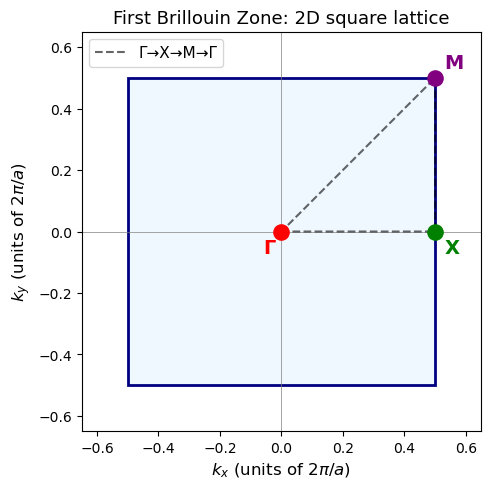

Γ (0,0): zone center  |  X (½,0): zone face  |  M (½,½): zone corner


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ─── 2D square lattice Brillouin zone with high-symmetry points ───
fig, ax = plt.subplots(figsize=(5, 5))

# First BZ is a square from (-π/a, -π/a) to (π/a, π/a)
# Use reduced coordinates: BZ boundary at ±0.5
a = 1.0  # lattice constant (arbitrary units)
bz_half = 0.5  # in units of 2π/a

# Draw the BZ square
bz = patches.Rectangle((-bz_half, -bz_half), 2*bz_half, 2*bz_half,
                        linewidth=2, edgecolor='navy', facecolor='aliceblue', zorder=1)
ax.add_patch(bz)

# High-symmetry points
hs_points = {
    'Γ': (0.0, 0.0),
    'X': (0.5, 0.0),
    'M': (0.5, 0.5),
}
colors = {'Γ': 'red', 'X': 'green', 'M': 'purple'}

for label, (kx, ky) in hs_points.items():
    ax.scatter(kx, ky, s=120, color=colors[label], zorder=5)
    offset = {'Γ': (-0.06, -0.07), 'X': (0.03, -0.07), 'M': (0.03, 0.03)}
    ax.annotate(label, (kx, ky), xytext=(kx + offset[label][0], ky + offset[label][1]),
                fontsize=14, fontweight='bold', color=colors[label])

# Draw high-symmetry path Γ→X→M→Γ
path = [(0.0, 0.0), (0.5, 0.0), (0.5, 0.5), (0.0, 0.0)]
px, py = zip(*path)
ax.plot(px, py, 'k--', lw=1.5, alpha=0.6, zorder=3, label='Γ→X→M→Γ')

ax.set_xlim(-0.65, 0.65)
ax.set_ylim(-0.65, 0.65)
ax.set_aspect('equal')
ax.set_xlabel('$k_x$ (units of $2\pi/a$)', fontsize=12)
ax.set_ylabel('$k_y$ (units of $2\pi/a$)', fontsize=12)
ax.set_title('First Brillouin Zone: 2D square lattice', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()
print("Γ (0,0): zone center  |  X (½,0): zone face  |  M (½,½): zone corner")

## 6. Further Reading

- Bloch, F. *Z. Physik* **52**, 555 (1929) — original Bloch theorem paper
- Kittel, C. *Introduction to Solid State Physics*, 8th ed. (Wiley, 2005)
- Sholl, D. S. & Steckel, J. A. *Density Functional Theory: A Practical Introduction* (Wiley, 2009) — excellent intro to periodic DFT
- Kresse, G. & Furthmüller, J. *Phys. Rev. B* **54**, 11169 (1996) — VASP
- [VASP Wiki: Theoretical Background](https://www.vasp.at/wiki/index.php/Theoretical_Background)
- [Quantum ESPRESSO: Theory](https://www.quantum-espresso.org/Doc/INPUT_PW.html)

---
*Ch121a | Caltech | Module 3 — Notebook 1 of 5*